# Visualisasi KPI — SIAKAD Data Warehouse
Notebook ini menampilkan visualisasi 4 KPI wajib berdasarkan hasil query Data Warehouse SIAKAD.

| KPI | Deskripsi |
|-----|----------|
| KPI 1 | Rasio Kelulusan Tepat Waktu per Prodi |
| KPI 2 | Tren IPK Rata-rata dari Tahun ke Tahun |
| KPI 3 | Korelasi UMP Provinsi Asal vs IPK |
| KPI 4 | Korelasi Akreditasi SMA Asal vs IPK |

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path

%matplotlib inline

BASE_DIR   = Path(r"E:\DW\siakad-data-warehouse")
DATA_DIR   = str(BASE_DIR / "data")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

print(f"Data diambil dari: {DATA_DIR}")

Data diambil dari: E:\DW\siakad-data-warehouse\data


## KPI 1 — Rasio Kelulusan Tepat Waktu per Prodi

In [25]:
df1 = pd.read_csv(os.path.join(DATA_DIR, "kpi1_rasio_kelulusan.csv"))
print(f"Data shape: {df1.shape}")
df1.head()

Data shape: (60, 6)


,nama_prodi,jenjang,tahun_akademik,total_mahasiswa_lulus,lulus_tepat_waktu,rasio_tepat_waktu_pct
0,Pendidikan Dokter,S1,2020,50,22,44.00
1,Matematika,S1,2020,80,26,32.50
2,Teknik Elektro,S1,2020,47,15,31.91
3,Pendidikan Bahasa Inggris,S1,2020,61,18,29.51
4,Manajemen,S1,2020,56,15,26.79


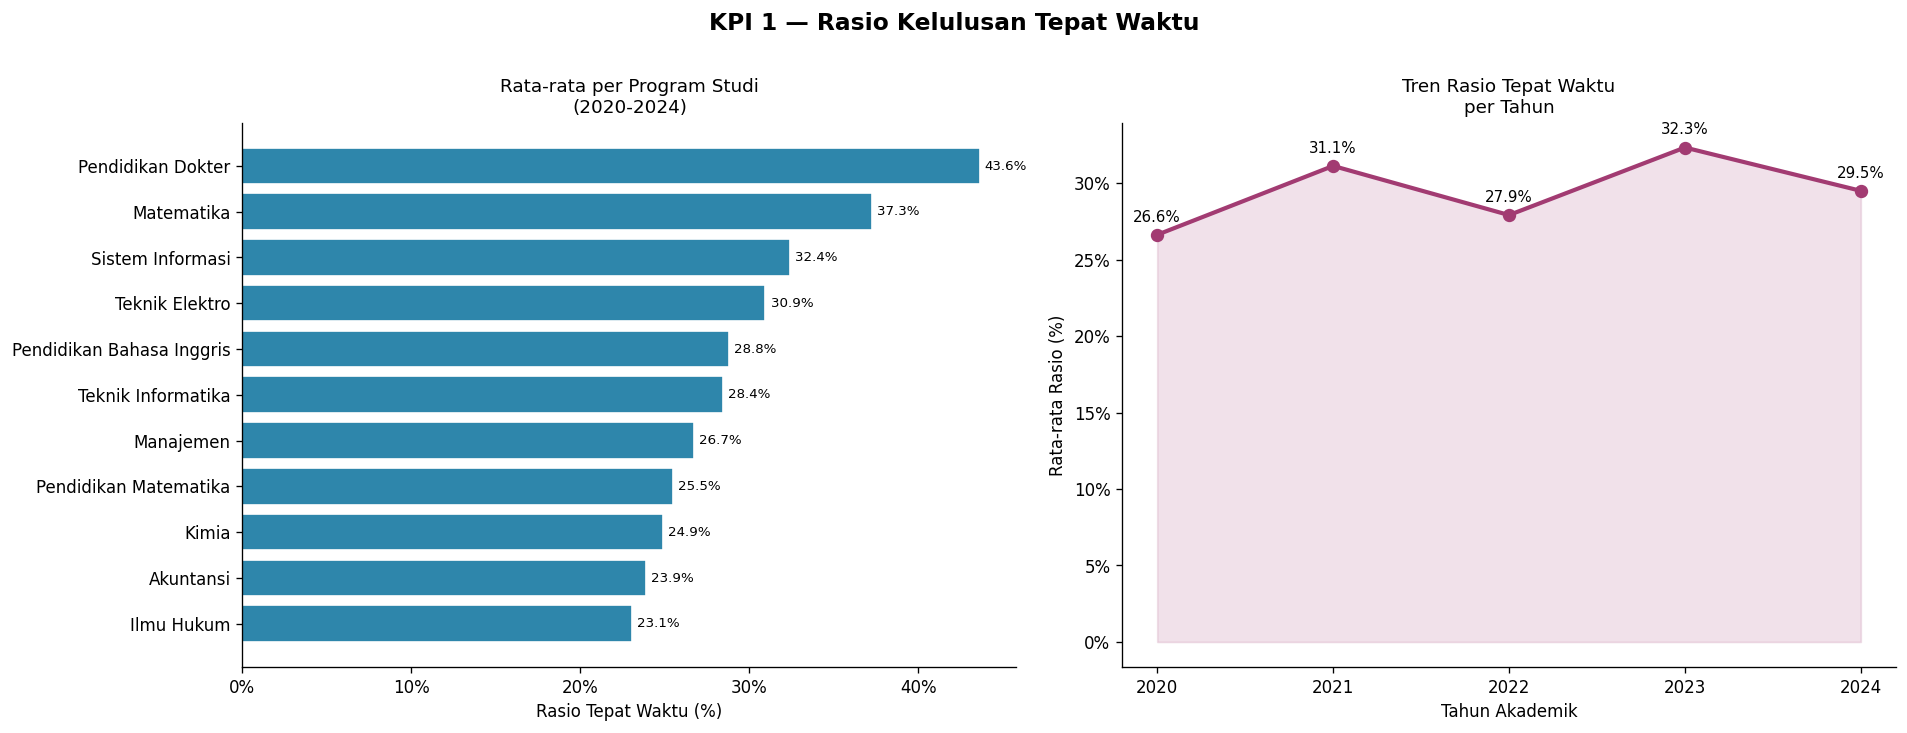

In [26]:
df1_avg = (df1.groupby("nama_prodi")["rasio_tepat_waktu_pct"]
             .mean()
             .sort_values(ascending=True)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 1 — Rasio Kelulusan Tepat Waktu", fontsize=14, fontweight="bold", y=1.01)

# Chart kiri: bar horizontal rata-rata per prodi
ax = axes[0]
bars = ax.barh(df1_avg["nama_prodi"], df1_avg["rasio_tepat_waktu_pct"],
               color="#2E86AB", edgecolor="white")
ax.set_xlabel("Rasio Tepat Waktu (%)")
ax.set_title("Rata-rata per Program Studi\n(2020-2024)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, df1_avg["rasio_tepat_waktu_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

# Chart kanan: tren per tahun
ax2 = axes[1]
df1_tren = (df1.groupby("tahun_akademik")["rasio_tepat_waktu_pct"]
              .mean().reset_index())
ax2.plot(df1_tren["tahun_akademik"], df1_tren["rasio_tepat_waktu_pct"],
         marker="o", color="#A23B72", linewidth=2.5, markersize=7)
ax2.fill_between(df1_tren["tahun_akademik"], df1_tren["rasio_tepat_waktu_pct"],
                 alpha=0.15, color="#A23B72")
for _, row in df1_tren.iterrows():
    ax2.annotate(f"{row['rasio_tepat_waktu_pct']:.1f}%",
                 (row["tahun_akademik"], row["rasio_tepat_waktu_pct"]),
                 textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.set_xlabel("Tahun Akademik")
ax2.set_ylabel("Rata-rata Rasio (%)")
ax2.set_title("Tren Rasio Tepat Waktu\nper Tahun", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_xticks(df1_tren["tahun_akademik"])

plt.tight_layout()
plt.show()

### 💡 Insight KPI 1
- Program studi dengan rasio kelulusan tepat waktu tertinggi dapat dijadikan benchmark
- Tren per tahun menunjukkan apakah kebijakan akademik berdampak positif atau tidak

## KPI 2 — Tren IPK Rata-rata per Semester

In [27]:
df2 = pd.read_csv(os.path.join(DATA_DIR, "kpi2_tren_ipk.csv"))
print(f"Data shape: {df2.shape}")
df2

Data shape: (10, 7)


,tahun_akademik,label_semester,periode_label,rata_rata_ipk,ipk_min,ipk_max,jumlah_mahasiswa
0,2020,Ganjil,Semester Ganjil 2020/2021,2.967,0.00,4.00,710
1,2020,Genap,Semester Genap 2020/2021,2.970,1.41,3.88,703
2,2021,Ganjil,Semester Ganjil 2021/2022,2.960,0.00,4.00,976
3,2021,Genap,Semester Genap 2021/2022,2.963,1.35,3.88,962
4,2022,Ganjil,Semester Ganjil 2022/2023,2.969,0.00,4.00,1088
5,2022,Genap,Semester Genap 2022/2023,2.967,1.86,3.84,960
6,2023,Ganjil,Semester Ganjil 2023/2024,2.975,0.00,4.00,936
7,2023,Genap,Semester Genap 2023/2024,2.966,1.43,3.80,725
8,2024,Ganjil,Semester Ganjil 2024/2025,2.971,1.81,3.65,393
9,2024,Genap,Semester Genap 2024/2025,2.982,1.91,3.54,170


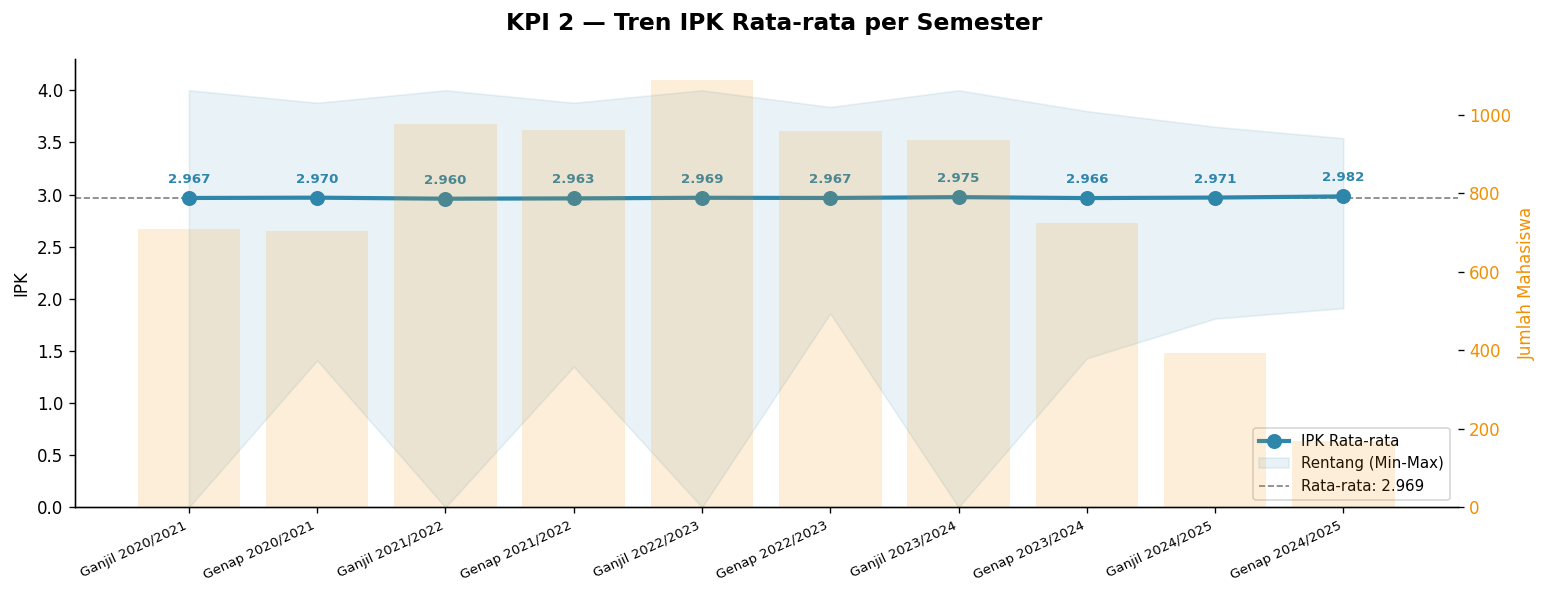

In [28]:
df2["label"] = df2["periode_label"].str.replace("Semester ", "", regex=False)

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("KPI 2 — Tren IPK Rata-rata per Semester", fontsize=14, fontweight="bold")

x = range(len(df2))
ax.plot(x, df2["rata_rata_ipk"], marker="o", color="#2E86AB",
        linewidth=2.5, markersize=8, label="IPK Rata-rata", zorder=3)
ax.fill_between(x, df2["ipk_min"], df2["ipk_max"],
                alpha=0.1, color="#2E86AB", label="Rentang (Min-Max)")
for i, row in df2.iterrows():
    ax.annotate(f"{row['rata_rata_ipk']:.3f}",
                (i, row["rata_rata_ipk"]),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color="#2E86AB", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df2["label"], rotation=25, ha="right", fontsize=8)
ax.set_ylabel("IPK")
ax.set_ylim(0, 4.3)
ax.axhline(df2["rata_rata_ipk"].mean(), color="gray", linestyle="--",
           linewidth=1, label=f"Rata-rata: {df2['rata_rata_ipk'].mean():.3f}")
ax.legend(fontsize=9)

ax_twin = ax.twinx()
ax_twin.bar(x, df2["jumlah_mahasiswa"], alpha=0.15, color="#F18F01", label="Jml Mahasiswa")
ax_twin.set_ylabel("Jumlah Mahasiswa", color="#F18F01")
ax_twin.tick_params(axis="y", labelcolor="#F18F01")
ax_twin.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

### 💡 Insight KPI 2
- IPK rata-rata yang stabil menunjukkan konsistensi kualitas akademik
- Perlu diperhatikan jika tren menurun bersamaan dengan kenaikan jumlah mahasiswa

## KPI 3 — Korelasi UMP Provinsi Asal vs IPK

In [29]:
df3 = pd.read_csv(os.path.join(DATA_DIR, "kpi3_korelasi_ump_ipk.csv"))
print(f"Data shape: {df3.shape}")
df3.head(10)

Data shape: (34, 5)


,nama_provinsi,kategori_ekonomi,ump_juta,rata_rata_ipk,jumlah_mahasiswa
0,DKI Jakarta,Tinggi,5.73,2.988,37
1,Papua,Tinggi,4.44,2.959,39
2,Bangka Belitung,Tinggi,4.04,3.003,55
3,Sulawesi Utara,Tinggi,4.00,2.995,47
4,Sumatera Selatan,Tinggi,3.94,2.893,46
5,Aceh,Tinggi,3.93,3.049,33
6,Sulawesi Selatan,Tinggi,3.92,2.911,45
7,Kepulauan Riau,Tinggi,3.88,2.951,50
8,Papua Barat,Tinggi,3.84,2.976,42
9,Riau,Tinggi,3.78,2.970,40


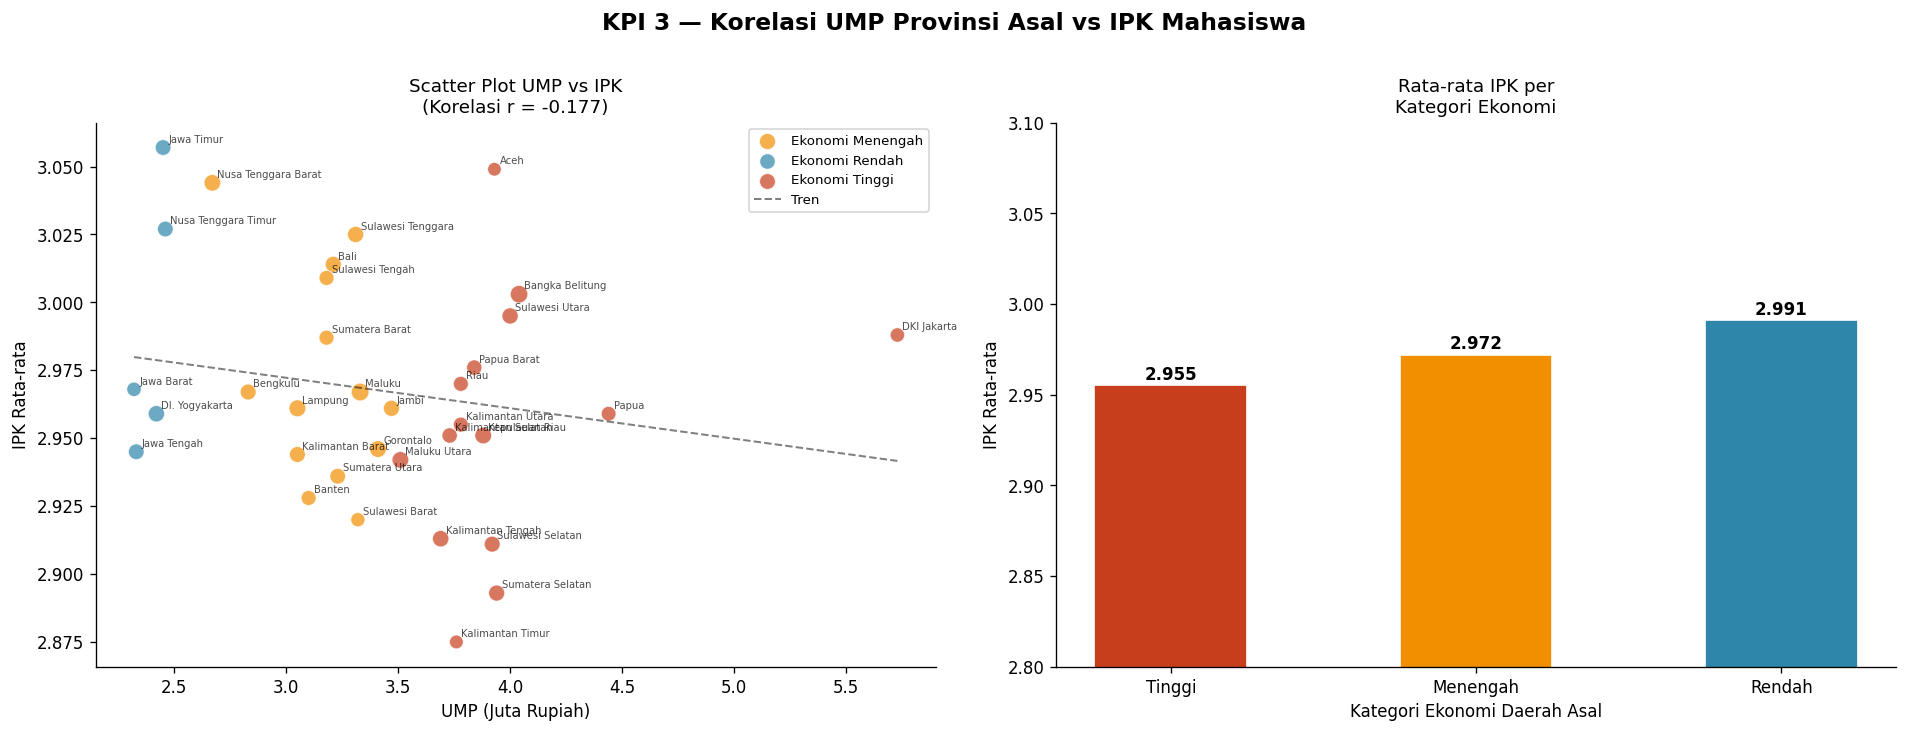

Nilai korelasi Pearson UMP vs IPK: r = -0.177


In [30]:
kategori_colors = {"Tinggi": "#C73E1D", "Menengah": "#F18F01", "Rendah": "#2E86AB"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 3 — Korelasi UMP Provinsi Asal vs IPK Mahasiswa",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
for kat, grp in df3.groupby("kategori_ekonomi"):
    ax.scatter(grp["ump_juta"], grp["rata_rata_ipk"],
               color=kategori_colors.get(kat, "gray"),
               label=f"Ekonomi {kat}", s=grp["jumlah_mahasiswa"]*2,
               alpha=0.7, edgecolors="white", linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["nama_provinsi"], (row["ump_juta"], row["rata_rata_ipk"]),
                    fontsize=6, alpha=0.7, xytext=(3, 3), textcoords="offset points")

z = np.polyfit(df3["ump_juta"], df3["rata_rata_ipk"], 1)
p = np.poly1d(z)
x_line = np.linspace(df3["ump_juta"].min(), df3["ump_juta"].max(), 100)
ax.plot(x_line, p(x_line), "k--", linewidth=1.2, alpha=0.5, label="Tren")

corr = df3["ump_juta"].corr(df3["rata_rata_ipk"])
ax.set_xlabel("UMP (Juta Rupiah)")
ax.set_ylabel("IPK Rata-rata")
ax.set_title(f"Scatter Plot UMP vs IPK\n(Korelasi r = {corr:.3f})", fontsize=11)
ax.legend(fontsize=8)

ax2 = axes[1]
df3_kat = (df3.groupby("kategori_ekonomi")
             .agg(rata_rata_ipk=("rata_rata_ipk", "mean"),
                  jumlah_mahasiswa=("jumlah_mahasiswa", "sum"))
             .reindex(["Tinggi", "Menengah", "Rendah"]).reset_index())
bars = ax2.bar(df3_kat["kategori_ekonomi"], df3_kat["rata_rata_ipk"],
               color=[kategori_colors[k] for k in df3_kat["kategori_ekonomi"]],
               width=0.5, edgecolor="white")
ax2.set_ylim(2.8, 3.1)
ax2.set_xlabel("Kategori Ekonomi Daerah Asal")
ax2.set_ylabel("IPK Rata-rata")
ax2.set_title("Rata-rata IPK per\nKategori Ekonomi", fontsize=11)
for bar, val in zip(bars, df3_kat["rata_rata_ipk"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Nilai korelasi Pearson UMP vs IPK: r = {corr:.3f}")

### 💡 Insight KPI 3
- Nilai r mendekati 0 menunjukkan korelasi lemah antara UMP dan IPK
- Artinya tingkat ekonomi daerah asal tidak terlalu menentukan performa akademik mahasiswa

## KPI 4 — Korelasi Akreditasi SMA Asal vs IPK

In [31]:
df4 = pd.read_csv(os.path.join(DATA_DIR, "kpi4_korelasi_akreditasi_ipk.csv"))
print(f"Data shape: {df4.shape}")
df4.head(10)

Data shape: (44, 5)


,akreditasi_sma,nama_prodi,rata_rata_ipk,rata_rata_nilai,jumlah_mahasiswa
0,A,Pendidikan Matematika,3.142,74.83,45
1,A,Ilmu Hukum,3.119,74.68,47
2,A,Manajemen,3.105,74.72,57
3,A,Akuntansi,3.091,74.61,56
4,A,Teknik Informatika,3.085,74.70,89
5,A,Sistem Informasi,3.068,74.40,35
6,A,Kimia,3.057,73.86,41
7,A,Pendidikan Dokter,3.055,74.52,51
8,A,Matematika,3.037,73.52,64
9,A,Pendidikan Bahasa Inggris,3.018,73.46,50


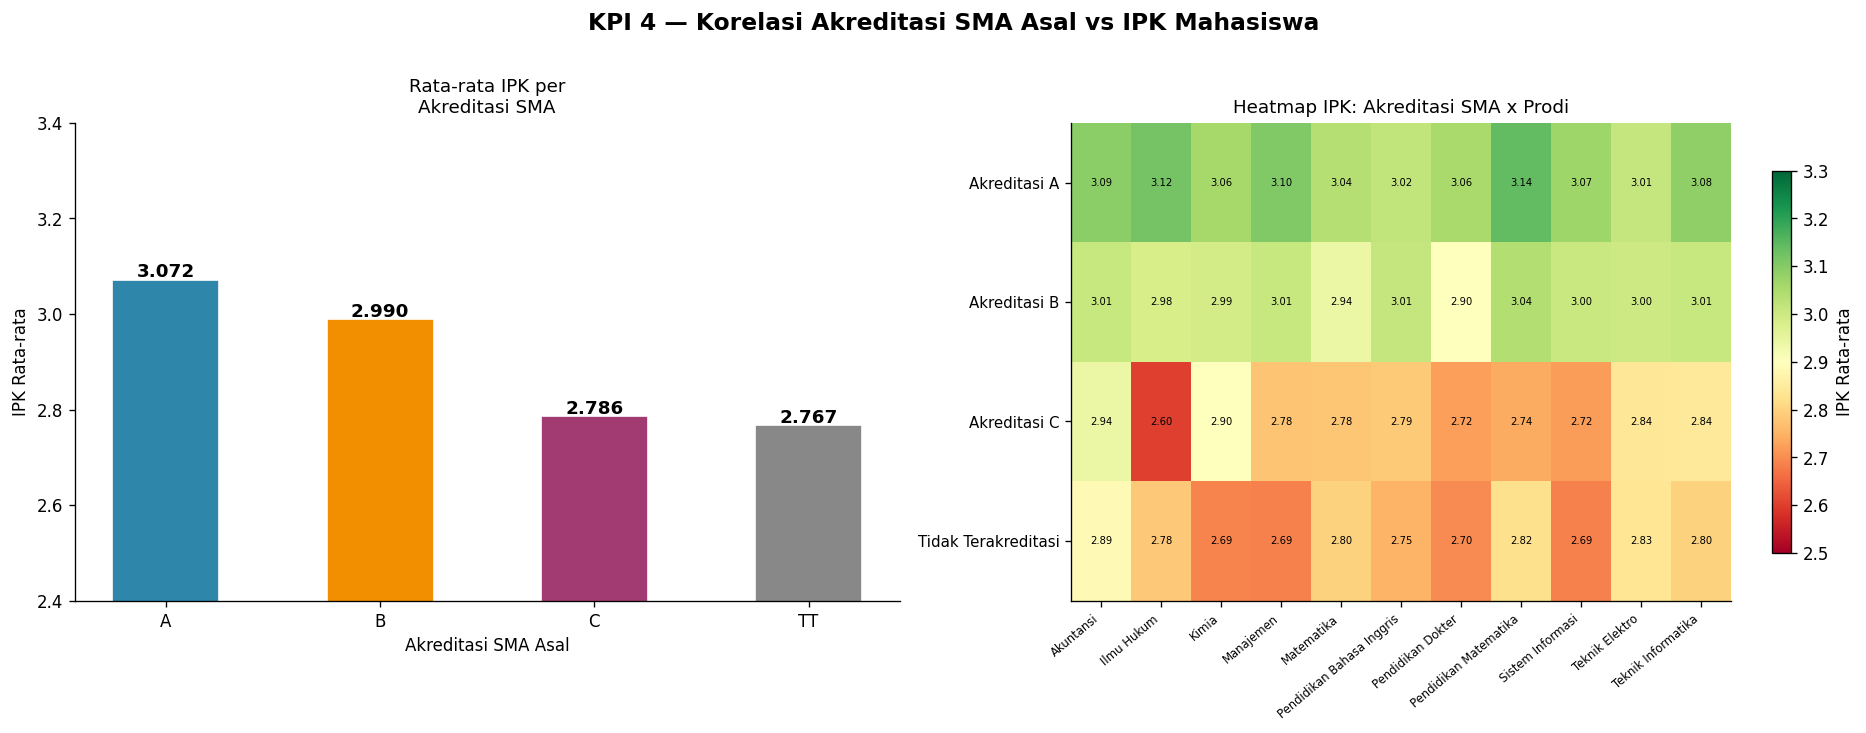

In [32]:
akr_order  = ["A", "B", "C", "TT"]
akr_colors = ["#2E86AB", "#F18F01", "#A23B72", "#888888"]
akr_labels = {"A": "Akreditasi A", "B": "Akreditasi B",
              "C": "Akreditasi C", "TT": "Tidak Terakreditasi"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("KPI 4 — Korelasi Akreditasi SMA Asal vs IPK Mahasiswa",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
df4_avg = (df4.groupby("akreditasi_sma")["rata_rata_ipk"]
             .mean().reindex(akr_order).reset_index())
bars = ax.bar(df4_avg["akreditasi_sma"], df4_avg["rata_rata_ipk"],
              color=akr_colors, width=0.5, edgecolor="white")
ax.set_ylim(2.4, 3.4)
ax.set_xlabel("Akreditasi SMA Asal")
ax.set_ylabel("IPK Rata-rata")
ax.set_title("Rata-rata IPK per\nAkreditasi SMA", fontsize=11)
for bar, val in zip(bars, df4_avg["rata_rata_ipk"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

ax2 = axes[1]
pivot = df4.pivot_table(index="akreditasi_sma", columns="nama_prodi",
                        values="rata_rata_ipk", aggfunc="mean")
pivot = pivot.reindex(akr_order)
im = ax2.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=2.5, vmax=3.3)
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns, rotation=40, ha="right", fontsize=7)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels([akr_labels[k] for k in pivot.index], fontsize=9)
ax2.set_title("Heatmap IPK: Akreditasi SMA x Prodi", fontsize=11)
plt.colorbar(im, ax=ax2, label="IPK Rata-rata", shrink=0.8)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=6, color="black")

plt.tight_layout()
plt.show()

### 💡 Insight KPI 4
- Mahasiswa dari SMA akreditasi A cenderung memiliki IPK lebih tinggi
- Heatmap menunjukkan pola ini konsisten di hampir semua program studi
- Akreditasi SMA dapat dijadikan salah satu pertimbangan dalam seleksi penerimaan mahasiswa baru